📂 Memuat data...
🚀 Fase Adaptasi TinyOL pada 1661 sampel...


100%|██████████| 1661/1661 [00:15<00:00, 110.23it/s]


✅ Adaptasi Selesai. Fase Evaluasi...


100%|██████████| 1661/1661 [00:11<00:00, 139.17it/s]


HASIL TINYOL ADAPTATION (DATA INDONESIA)
              precision    recall  f1-score   support

       Noise       0.66      0.80      0.72      1661
       Gempa       0.74      0.58      0.65      1661

    accuracy                           0.69      3322
   macro avg       0.70      0.69      0.69      3322
weighted avg       0.70      0.69      0.69      3322



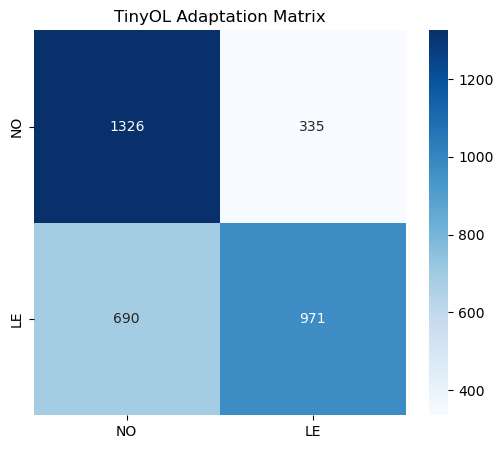

In [4]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

# ==============================================================================
# KONFIGURASI
# ==============================================================================
# Path Model (Pastikan path ini menuju folder model yang berisi file 'saved_model.pb' atau sejenisnya)
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
JSON_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json'
NUM_POINTS = 700

# ==============================================================================
# 1. ARSITEKTUR TINYOL
# ==============================================================================
def get_tinyol_model(base_model_path):
    # Streamline Keras loading (mengatasi potensi error format model)
    base_model = keras.models.load_model(base_model_path)
    # Ambil extractor (misal layer 'dense_1')
    extractor = keras.Model(inputs=base_model.input, outputs=base_model.get_layer('dense_1').output)
    
    # TinyOL Head: Layer klasifikasi kecil (Tiny)
    # Inputnya adalah ukuran output layer dense_1
    head_input = keras.Input(shape=(extractor.output_shape[1],))
    head_output = keras.layers.Dense(1, activation='sigmoid', name='tinyol_head')(head_input)
    tinyol_head = keras.Model(inputs=head_input, outputs=head_output)
    
    return extractor, tinyol_head

# ==============================================================================
# 2. TRAINING STEP (SGD)
# ==============================================================================
@tf.function
def train_step(model, optimizer, x, y):
    with tf.GradientTape() as tape:
        logits = model(x, training=True)
        # Binary Cross Entropy untuk deteksi Gempa vs Noise
        loss = tf.keras.losses.binary_crossentropy(y, logits)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

def main():
    extractor, tinyol_head = get_tinyol_model(MODEL_PATH)
    optimizer = keras.optimizers.SGD(learning_rate=0.05)
    
    print("📂 Memuat data...")
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)
    
    # Pisahkan fitur dan label
    keys = list(data.keys())
    # Kita gunakan 50% awal untuk adaptasi (streaming), sisanya untuk tes
    split = int(len(keys) * 0.5)
    train_keys = keys[:split]
    test_keys = keys[split:]
    
    print(f"🚀 Fase Adaptasi TinyOL pada {len(train_keys)} sampel...")
    for key in tqdm(train_keys):
        rec = data[key]
        if "Z" in rec and len(rec["Z"]) >= NUM_POINTS:
            # Sinyal Gempa (Label 1)
            feat = extractor(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), training=False)
            train_step(tinyol_head, optimizer, feat, np.array([[1.0]]))
            
        if "Z_noise" in rec and len(rec["Z_noise"]) >= NUM_POINTS:
            # Sinyal Noise (Label 0)
            feat = extractor(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), training=False)
            train_step(tinyol_head, optimizer, feat, np.array([[0.0]]))

    print("✅ Adaptasi Selesai. Fase Evaluasi...")
    
    y_true, y_pred = [], []
    for key in tqdm(test_keys):
        rec = data[key]
        if "Z" in rec:
            feat = extractor(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), training=False)
            prob = tinyol_head(feat).numpy()[0][0]
            y_pred.append(1 if prob > 0.5 else 0)
            y_true.append(1)
        if "Z_noise" in rec:
            feat = extractor(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), training=False)
            prob = tinyol_head(feat).numpy()[0][0]
            y_pred.append(1 if prob > 0.5 else 0)
            y_true.append(0)

    print("\n" + "="*50)
    print("HASIL TINYOL ADAPTATION (DATA INDONESIA)")
    print("="*50)
    print(classification_report(y_true, y_pred, target_names=['Noise', 'Gempa']))
    
    # Plot Matriks Konfusi
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'LE'], yticklabels=['NO', 'LE'])
    plt.title("TinyOL Adaptation Matrix")
    plt.show()

if __name__ == "__main__":
    main()


📂 Memuat data...
🚀 Fase Adaptasi TinyOL (5 Epochs)...
--- Epoch 1/5 ---


100%|██████████| 1328/1328 [00:14<00:00, 93.11it/s] 


--- Epoch 2/5 ---


100%|██████████| 1328/1328 [00:13<00:00, 100.22it/s]


--- Epoch 3/5 ---


...

100%|██████████| 1328/1328 [00:14<00:00, 91.90it/s]


--- Epoch 5/5 ---


100%|██████████| 1328/1328 [00:13<00:00, 94.97it/s]


✅ Evaluasi...


100%|██████████| 1994/1994 [00:15<00:00, 128.83it/s]


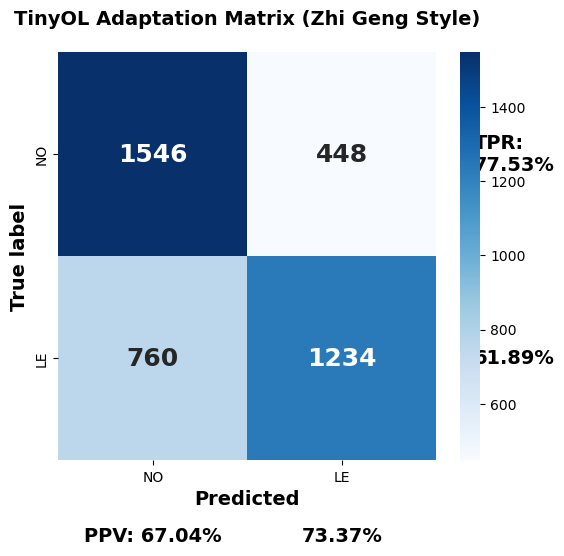

              precision    recall  f1-score   support

       Noise       0.67      0.78      0.72      1994
       Gempa       0.73      0.62      0.67      1994

    accuracy                           0.70      3988
   macro avg       0.70      0.70      0.70      3988
weighted avg       0.70      0.70      0.70      3988



In [13]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ==============================================================================
# KONFIGURASI OPTIMAL
# ==============================================================================
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
JSON_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json'
NUM_POINTS = 700
LEARNING_RATE = 0.05
EPOCHS = 5

def get_tinyol_model(base_model_path):
    base_model = keras.models.load_model(base_model_path)
    extractor = keras.Model(inputs=base_model.input, outputs=base_model.get_layer('dense_1').output)
    
    head_input = keras.Input(shape=(extractor.output_shape[1],))
    head_output = keras.layers.Dense(1, activation='sigmoid', name='tinyol_head')(head_input)
    tinyol_head = keras.Model(inputs=head_input, outputs=head_output)
    
    return extractor, tinyol_head

@tf.function
def train_step(model, optimizer, x, y):
    with tf.GradientTape() as tape:
        logits = model(x, training=True)
        loss = tf.keras.losses.binary_crossentropy(y, logits)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

def main():
    extractor, tinyol_head = get_tinyol_model(MODEL_PATH)
    optimizer = keras.optimizers.SGD(learning_rate=LEARNING_RATE)
    
    print("📂 Memuat data...")
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)
    
    keys = list(data.keys())
    split = int(len(keys) * 0.4)  # 60% untuk adaptasi, 40% untuk tes
    train_keys = keys[:split]
    test_keys = keys[split:]
    
    # --- FASE ADAPTASI ---
    print(f"🚀 Fase Adaptasi TinyOL ({EPOCHS} Epochs)...")
    loss_history = []
    
    for epoch in range(EPOCHS):
        print(f"--- Epoch {epoch+1}/{EPOCHS} ---")
        for key in tqdm(train_keys):
            rec = data[key]
            if "Z" in rec and len(rec["Z"]) >= NUM_POINTS:
                feat = extractor(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), training=False)
                loss = train_step(tinyol_head, optimizer, feat, np.array([[1.0]]))
                loss_history.append(loss.numpy())
            if "Z_noise" in rec and len(rec["Z_noise"]) >= NUM_POINTS:
                feat = extractor(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), training=False)
                loss = train_step(tinyol_head, optimizer, feat, np.array([[0.0]]))
                loss_history.append(loss.numpy())

    # --- FASE EVALUASI & VISUALISASI ALA ZHI GENG ---
    print("✅ Evaluasi...")
    y_true, y_pred = [], []
    for key in tqdm(test_keys):
        rec = data[key]
        if "Z" in rec:
            feat = extractor(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), training=False)
            prob = tinyol_head(feat).numpy()[0][0]
            y_pred.append(1 if prob > 0.5 else 0); y_true.append(1)
        if "Z_noise" in rec:
            feat = extractor(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), training=False)
            prob = tinyol_head(feat).numpy()[0][0]
            y_pred.append(1 if prob > 0.5 else 0); y_true.append(0)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    tpr_no = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0
    tpr_le = (tp / (fn + tp)) * 100 if (fn + tp) > 0 else 0
    ppv_no = (tn / (tn + fn)) * 100 if (tn + fn) > 0 else 0
    ppv_le = (tp / (fp + tp)) * 100 if (fp + tp) > 0 else 0

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['NO', 'LE'], yticklabels=['NO', 'LE'],
                annot_kws={"size": 18, "weight": "bold"})
    
    plt.text(2.2, 0.5, f"TPR:\n{tpr_no:.2f}%", va='center', fontsize=14, fontweight='bold')
    plt.text(2.2, 1.5, f"{tpr_le:.2f}%", va='center', fontsize=14, fontweight='bold')
    plt.text(0.5, 2.4, f"PPV: {ppv_no:.2f}%", ha='center', fontsize=14, fontweight='bold')
    plt.text(1.5, 2.4, f"{ppv_le:.2f}%", ha='center', fontsize=14, fontweight='bold')
    
    plt.title("TinyOL Adaptation Matrix (Zhi Geng Style)", fontsize=14, pad=20, fontweight='bold')
    plt.xlabel('Predicted', fontsize=14, fontweight='bold')
    plt.ylabel('True label', fontsize=14, fontweight='bold')
    plt.subplots_adjust(right=0.8, bottom=0.2)
    plt.show()

    print(classification_report(y_true, y_pred, target_names=['Noise', 'Gempa']))

if __name__ == "__main__":
    main()

📂 Memuat data...
🚀 Fase Adaptasi TinyOL (3 Epochs)...
--- Epoch 1/3 ---


100%|██████████| 1661/1661 [00:17<00:00, 94.24it/s]


--- Epoch 2/3 ---


100%|██████████| 1661/1661 [00:17<00:00, 96.17it/s] 


--- Epoch 3/3 ---


100%|██████████| 1661/1661 [00:17<00:00, 94.96it/s] 


✅ Evaluasi...


100%|██████████| 1661/1661 [00:13<00:00, 125.48it/s]


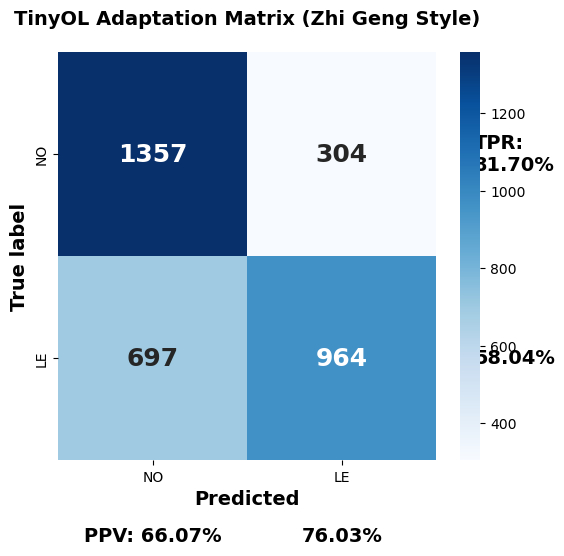

              precision    recall  f1-score   support

       Noise       0.66      0.82      0.73      1661
       Gempa       0.76      0.58      0.66      1661

    accuracy                           0.70      3322
   macro avg       0.71      0.70      0.69      3322
weighted avg       0.71      0.70      0.69      3322



In [15]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ==============================================================================
# KONFIGURASI OPTIMAL
# ==============================================================================
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
JSON_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json'
NUM_POINTS = 700
LEARNING_RATE = 0.05
EPOCHS = 3

def get_tinyol_model(base_model_path):
    base_model = keras.models.load_model(base_model_path)
    extractor = keras.Model(inputs=base_model.input, outputs=base_model.get_layer('dense_1').output)
    
    head_input = keras.Input(shape=(extractor.output_shape[1],))
    head_output = keras.layers.Dense(1, activation='sigmoid', name='tinyol_head')(head_input)
    tinyol_head = keras.Model(inputs=head_input, outputs=head_output)
    
    return extractor, tinyol_head

@tf.function
def train_step(model, optimizer, x, y):
    with tf.GradientTape() as tape:
        logits = model(x, training=True)
        loss = tf.keras.losses.binary_crossentropy(y, logits)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

def main():
    extractor, tinyol_head = get_tinyol_model(MODEL_PATH)
    optimizer = keras.optimizers.SGD(learning_rate=LEARNING_RATE)
    
    print("📂 Memuat data...")
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)
    
    keys = list(data.keys())
    split = int(len(keys) * 0.5)  # 50% untuk adaptasi, 50% untuk tes
    train_keys = keys[:split]
    test_keys = keys[split:]
    
    # --- FASE ADAPTASI ---
    print(f"🚀 Fase Adaptasi TinyOL ({EPOCHS} Epochs)...")
    loss_history = []
    
    for epoch in range(EPOCHS):
        print(f"--- Epoch {epoch+1}/{EPOCHS} ---")
        for key in tqdm(train_keys):
            rec = data[key]
            if "Z" in rec and len(rec["Z"]) >= NUM_POINTS:
                feat = extractor(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), training=False)
                loss = train_step(tinyol_head, optimizer, feat, np.array([[1.0]]))
                loss_history.append(loss.numpy())
            if "Z_noise" in rec and len(rec["Z_noise"]) >= NUM_POINTS:
                feat = extractor(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), training=False)
                loss = train_step(tinyol_head, optimizer, feat, np.array([[0.0]]))
                loss_history.append(loss.numpy())

    # --- FASE EVALUASI & VISUALISASI ALA ZHI GENG ---
    print("✅ Evaluasi...")
    y_true, y_pred = [], []
    for key in tqdm(test_keys):
        rec = data[key]
        if "Z" in rec:
            feat = extractor(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), training=False)
            prob = tinyol_head(feat).numpy()[0][0]
            y_pred.append(1 if prob > 0.5 else 0); y_true.append(1)
        if "Z_noise" in rec:
            feat = extractor(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), training=False)
            prob = tinyol_head(feat).numpy()[0][0]
            y_pred.append(1 if prob > 0.5 else 0); y_true.append(0)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    tpr_no = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0
    tpr_le = (tp / (fn + tp)) * 100 if (fn + tp) > 0 else 0
    ppv_no = (tn / (tn + fn)) * 100 if (tn + fn) > 0 else 0
    ppv_le = (tp / (fp + tp)) * 100 if (fp + tp) > 0 else 0

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['NO', 'LE'], yticklabels=['NO', 'LE'],
                annot_kws={"size": 18, "weight": "bold"})
    
    plt.text(2.2, 0.5, f"TPR:\n{tpr_no:.2f}%", va='center', fontsize=14, fontweight='bold')
    plt.text(2.2, 1.5, f"{tpr_le:.2f}%", va='center', fontsize=14, fontweight='bold')
    plt.text(0.5, 2.4, f"PPV: {ppv_no:.2f}%", ha='center', fontsize=14, fontweight='bold')
    plt.text(1.5, 2.4, f"{ppv_le:.2f}%", ha='center', fontsize=14, fontweight='bold')
    
    plt.title("TinyOL Adaptation Matrix (Zhi Geng Style)", fontsize=14, pad=20, fontweight='bold')
    plt.xlabel('Predicted', fontsize=14, fontweight='bold')
    plt.ylabel('True label', fontsize=14, fontweight='bold')
    plt.subplots_adjust(right=0.8, bottom=0.2)
    plt.show()

    print(classification_report(y_true, y_pred, target_names=['Noise', 'Gempa']))

if __name__ == "__main__":
    main()

🚀 Fase Adaptasi TinyOL (3 Epochs)...


Epoch 3: 100%|██████████| 1328/1328 [00:13<00:00, 98.73it/s] 


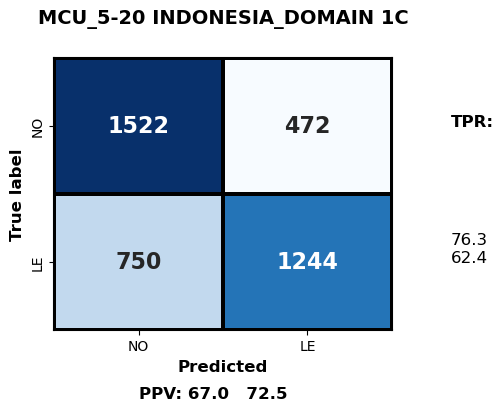

In [17]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ==============================================================================
# KONFIGURASI
# ==============================================================================
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
JSON_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json'
NUM_POINTS = 700
LEARNING_RATE = 0.05
EPOCHS = 3

def get_tinyol_model(base_model_path):
    base_model = keras.models.load_model(base_model_path)
    extractor = keras.Model(inputs=base_model.input, outputs=base_model.get_layer('dense_1').output)
    head_input = keras.Input(shape=(extractor.output_shape[1],))
    head_output = keras.layers.Dense(1, activation='sigmoid', name='tinyol_head')(head_input)
    tinyol_head = keras.Model(inputs=head_input, outputs=head_output)
    return extractor, tinyol_head

@tf.function
def train_step(model, optimizer, x, y):
    with tf.GradientTape() as tape:
        logits = model(x, training=True)
        loss = tf.keras.losses.binary_crossentropy(y, logits)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

def plot_zhi_geng_exact(cm, title):
    # tn=0,0; fp=0,1; fn=1,0; tp=1,1
    tn, fp, fn, tp = cm.ravel()
    
    tpr_no = (tn / (tn + fp)) * 100 
    tpr_le = (tp / (fn + tp)) * 100 
    ppv_no = (tn / (tn + fn)) * 100 
    ppv_le = (tp / (fp + tp)) * 100 

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar=False, annot_kws={"size": 16, "weight": "bold"},
                xticklabels=['NO', 'LE'], yticklabels=['NO', 'LE'],
                linecolor='black', linewidths=1.5)
    
    # Border tegas
    for _, spine in ax.spines.items():
        spine.set_visible(True); spine.set_color('black'); spine.set_linewidth(1.5)

    # Label TPR (kanan)
    plt.text(2.35, 0.5, "TPR:", fontsize=12, fontweight='bold')
    plt.text(2.35, 1.5, f"{tpr_no:.1f}\n{tpr_le:.1f}", fontsize=12)
    
    # Label PPV (bawah)
    plt.text(0.5, 2.5, f"PPV: {ppv_no:.1f}   {ppv_le:.1f}", fontsize=12, fontweight='bold')
    
    plt.title(title, fontsize=14, pad=25, fontweight='bold')
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('True label', fontsize=12, fontweight='bold')
    plt.subplots_adjust(right=0.8, bottom=0.2)
    plt.show()

def main():
    extractor, tinyol_head = get_tinyol_model(MODEL_PATH)
    optimizer = keras.optimizers.SGD(learning_rate=LEARNING_RATE)
    
    with open(JSON_PATH, 'r') as f: data = json.load(f)
    keys = list(data.keys())
    split = int(len(keys) * 0.4)
    train_keys, test_keys = keys[:split], keys[split:]
    
    print(f"🚀 Fase Adaptasi TinyOL ({EPOCHS} Epochs)...")
    loss_history = []
    
    for epoch in range(EPOCHS):
        for key in tqdm(train_keys, desc=f"Epoch {epoch+1}"):
            rec = data[key]
            if "Z" in rec and len(rec["Z"]) >= NUM_POINTS:
                feat = extractor(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), training=False)
                loss = train_step(tinyol_head, optimizer, feat, np.array([[1.0]]))
                loss_history.append(loss.numpy())
            if "Z_noise" in rec and len(rec["Z_noise"]) >= NUM_POINTS:
                feat = extractor(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), training=False)
                loss = train_step(tinyol_head, optimizer, feat, np.array([[0.0]]))
                loss_history.append(loss.numpy())

    # Evaluasi
    y_true, y_pred = [], []
    for key in test_keys:
        rec = data[key]
        if "Z" in rec:
            feat = extractor(np.array(rec["Z"][:NUM_POINTS]).reshape(1, NUM_POINTS, 1), training=False)
            prob = tinyol_head(feat).numpy()[0][0]
            y_pred.append(1 if prob > 0.5 else 0); y_true.append(1)
        if "Z_noise" in rec:
            feat = extractor(np.array(rec["Z_noise"][-NUM_POINTS:]).reshape(1, NUM_POINTS, 1), training=False)
            prob = tinyol_head(feat).numpy()[0][0]
            y_pred.append(1 if prob > 0.5 else 0); y_true.append(0)

    # Plot Hasil
    plot_zhi_geng_exact(confusion_matrix(y_true, y_pred, labels=[0, 1]), "MCU_5-20 INDONESIA_DOMAIN 1C")

if __name__ == "__main__":
    main()

Adaptasi TinyOL: 100%|██████████| 1328/1328 [00:21<00:00, 60.57it/s]


Hasil tersimpan di: /Volumes/Extreme SSD/json_indonesia_juli_sesi_4/output_tinyol


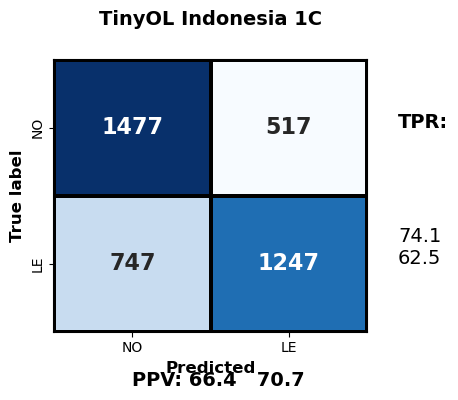

In [19]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==============================================================================
# 1. FUNGSI VISUALISASI "ZHI GENG STYLE"
# ==============================================================================
def plot_zhi_geng_style(cm, title):
    tn, fp, fn, tp = cm.ravel()
    tpr_no = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0
    tpr_le = (tp / (fn + tp)) * 100 if (fn + tp) > 0 else 0
    ppv_no = (tn / (tn + fn)) * 100 if (tn + fn) > 0 else 0
    ppv_le = (tp / (fp + tp)) * 100 if (fp + tp) > 0 else 0

    plt.figure(figsize=(5, 4))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                     cbar=False, annot_kws={"size": 16, "weight": "bold"},
                     xticklabels=['NO', 'LE'], yticklabels=['NO', 'LE'],
                     linecolor='black', linewidths=1.5)
    
    for _, spine in ax.spines.items():
        spine.set_visible(True); spine.set_color('black'); spine.set_linewidth(1.5)

    plt.text(2.2, 0.5, "TPR:", fontsize=14, fontweight='bold')
    plt.text(2.2, 1.5, f"{tpr_no:.1f}\n{tpr_le:.1f}", fontsize=14)
    plt.text(0.5, 2.4, f"PPV: {ppv_no:.1f}   {ppv_le:.1f}", fontsize=14, fontweight='bold')
    
    plt.title(title, fontsize=14, pad=25, fontweight='bold')
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('True label', fontsize=12, fontweight='bold')
    plt.subplots_adjust(right=0.75, bottom=0.2)
    return plt.gcf()

# ==============================================================================
# 2. MAIN EXECUTION (TINYOL INTEGRATED)
# ==============================================================================
if __name__ == "__main__":
    KEY_DATA_DIR = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4'
    KEY_TEST_FILE = "extracted_data_1c_4_SNR_HIGH.json"
    MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
    
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    SAVE_DIR = os.path.join(KEY_DATA_DIR, 'output_tinyol')
    os.makedirs(SAVE_DIR, exist_ok=True)

    # Inisialisasi Model & TinyOL Head
    base_model = keras.models.load_model(MODEL_PATH)
    extractor = keras.Model(inputs=base_model.input, outputs=base_model.get_layer('dense_1').output)
    tinyol_head = keras.Sequential([keras.layers.Dense(1, activation='sigmoid')])
    optimizer = keras.optimizers.SGD(learning_rate=0.05)

    keys = list(test_data.keys())
    split = int(len(keys) * 0.4)
    train_keys, test_keys = keys[:split], keys[split:]

    # FASE ADAPTASI (TinyOL)
    for key in tqdm(train_keys, desc="Adaptasi TinyOL"):
        rec = test_data[key]
        if "Z" in rec:
            feat = extractor(np.array(rec["Z"][:700]).reshape(1, 700, 1), training=False)
            with tf.GradientTape() as tape:
                loss = tf.keras.losses.binary_crossentropy(np.array([[1.0]]), tinyol_head(feat, training=True))
            optimizer.apply_gradients(zip(tape.gradient(loss, tinyol_head.trainable_variables), tinyol_head.trainable_variables))
        if "Z_noise" in rec:
            feat = extractor(np.array(rec["Z_noise"][-700:]).reshape(1, 700, 1), training=False)
            with tf.GradientTape() as tape:
                loss = tf.keras.losses.binary_crossentropy(np.array([[0.0]]), tinyol_head(feat, training=True))
            optimizer.apply_gradients(zip(tape.gradient(loss, tinyol_head.trainable_variables), tinyol_head.trainable_variables))

    # FASE EVALUASI
    y_true, y_pred = [], []
    for key in test_keys:
        rec = test_data[key]
        if "Z" in rec:
            feat = extractor(np.array(rec["Z"][:700]).reshape(1, 700, 1), training=False)
            y_pred.append(1 if tinyol_head(feat).numpy()[0][0] > 0.5 else 0); y_true.append(1)
        if "Z_noise" in rec:
            feat = extractor(np.array(rec["Z_noise"][-700:]).reshape(1, 700, 1), training=False)
            y_pred.append(1 if tinyol_head(feat).numpy()[0][0] > 0.5 else 0); y_true.append(0)

    # Plot
    fig = plot_zhi_geng_style(confusion_matrix(y_true, y_pred, labels=[0, 1]), "TinyOL Indonesia 1C")
    fig.savefig(os.path.join(SAVE_DIR, "tinyol_zhi_style.jpg"), dpi=300)
    print(f"Hasil tersimpan di: {SAVE_DIR}")